In [2]:
%reload_ext autoreload
%autoreload 2

In [32]:
import dataprocess as dp
import networkx as nx
import matplotlib.pyplot as plt
import numpy as np
import kmapper as km
from cereeberus import Interleave, ReebGraph, MapperGraph, Assignment

In [13]:
G, heights = dp.read_mapper("mapper_graph_layer_9.json")

G.nodes(data=True)

NodeDataView({'cube2_cluster0': {'f': np.float64(12.90592725773909)}, 'cube3_cluster0': {'f': np.float64(12.996847383297402)}, 'cube4_cluster0': {'f': np.float64(13.184153277883851)}, 'cube5_cluster0': {'f': np.float64(13.37170637176731)}, 'cube6_cluster0': {'f': np.float64(13.598784257968452)}, 'cube7_cluster0': {'f': np.float64(13.787048926918132)}, 'cube8_cluster0': {'f': np.float64(13.966827163287189)}, 'cube9_cluster0': {'f': np.float64(14.186983847326397)}, 'cube10_cluster0': {'f': np.float64(14.392089805965504)}, 'cube11_cluster0': {'f': np.float64(14.583729169175761)}, 'cube12_cluster0': {'f': np.float64(14.790945853395723)}, 'cube13_cluster0': {'f': np.float64(14.985332295954413)}, 'cube14_cluster0': {'f': np.float64(15.182737464747047)}, 'cube15_cluster0': {'f': np.float64(15.394670896864499)}, 'cube16_cluster0': {'f': np.float64(15.606878644626)}, 'cube17_cluster0': {'f': np.float64(15.795064937164103)}, 'cube18_cluster0': {'f': np.float64(15.99992166576412)}, 'cube19_cluste

In [14]:
heights

{'cube2_cluster0': 129,
 'cube3_cluster0': 130,
 'cube4_cluster0': 132,
 'cube5_cluster0': 134,
 'cube6_cluster0': 136,
 'cube7_cluster0': 138,
 'cube8_cluster0': 140,
 'cube9_cluster0': 142,
 'cube10_cluster0': 144,
 'cube11_cluster0': 146,
 'cube12_cluster0': 148,
 'cube13_cluster0': 150,
 'cube14_cluster0': 152,
 'cube15_cluster0': 154,
 'cube16_cluster0': 156,
 'cube17_cluster0': 158,
 'cube18_cluster0': 160,
 'cube19_cluster0': 162,
 'cube20_cluster0': 164,
 'cube21_cluster0': 166,
 'cube22_cluster0': 168,
 'cube23_cluster0': 170,
 'cube24_cluster0': 172,
 'cube25_cluster0': 174,
 'cube26_cluster0': 176,
 'cube26_cluster1': 176,
 'cube27_cluster0': 178,
 'cube27_cluster1': 178,
 'cube27_cluster2': 178,
 'cube28_cluster0': 180,
 'cube28_cluster1': 180,
 'cube28_cluster2': 180,
 'cube29_cluster0': 182,
 'cube29_cluster1': 182,
 'cube29_cluster2': 182,
 'cube30_cluster0': 184,
 'cube31_cluster0': 186,
 'cube32_cluster0': 188,
 'cube32_cluster1': 188,
 'cube33_cluster0': 190,
 'cube33

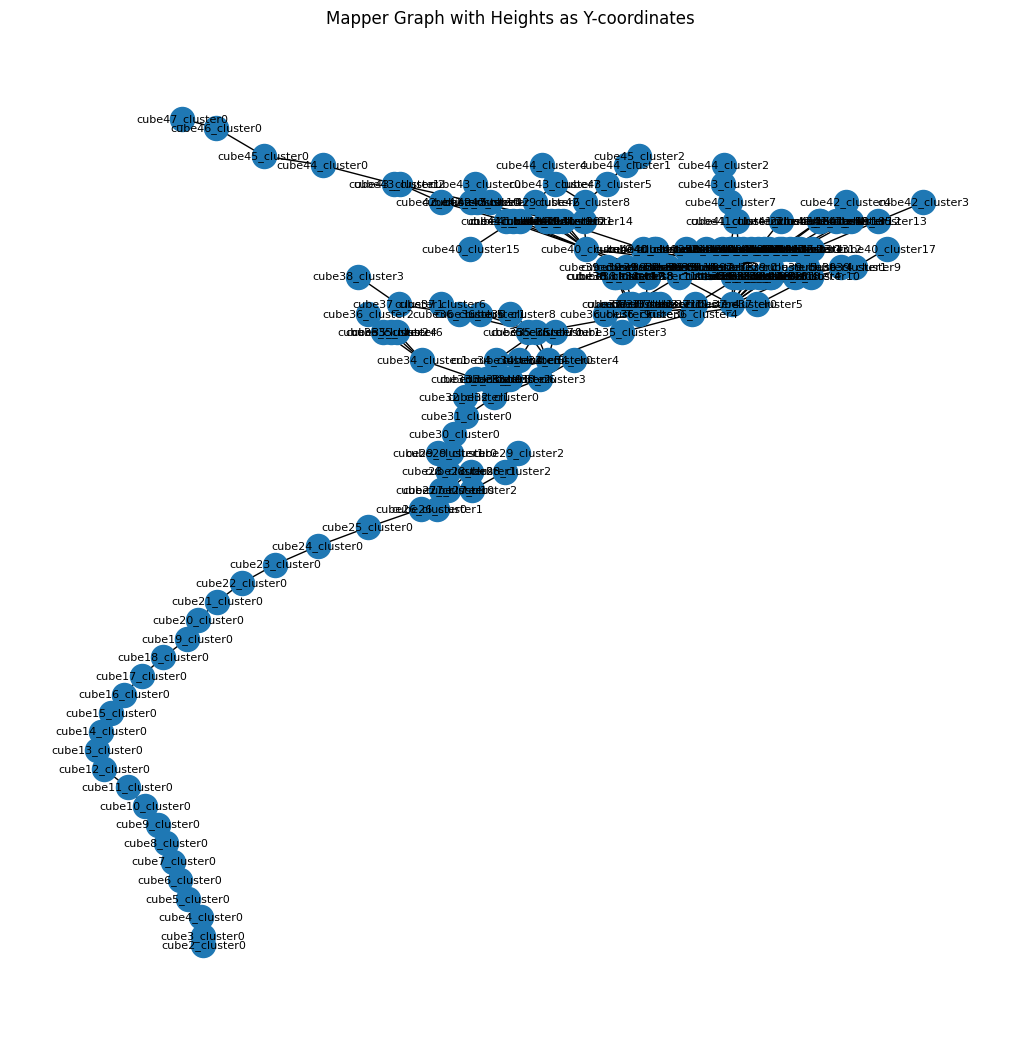

In [15]:
# draw the graph where the heights are the y-coordinates

plt.figure(figsize=(10, 10))
pos = nx.spring_layout(G, dim=2, seed=42)
pos = {k: (v[0], heights[k]) for k, v in pos.items()}
nx.draw(G, pos, with_labels=True, node_size=300, font_size=8)
labels = nx.get_edge_attributes(G, 'weight')
nx.draw_networkx_edge_labels(G, pos, edge_labels=labels)
plt.title("Mapper Graph with Heights as Y-coordinates")
plt.show()

In [30]:
mG.check_integer_grid_vertices()

All integer grid points have a vertex.


In [23]:
read_layers = {}
for i in range(3, 13):
    G, heights = dp.read_mapper(f"mapper_graph_layer_{i}.json")
    mG = MapperGraph(G, heights)
    read_layers[i] = mG


In [29]:
myInt = Interleave(read_layers[8], read_layers[9])


In [31]:
myInt.fit(verbose=True )


Finding interleaving distance between Mapper graphs F and G with function ranges [143, 215] and [129, 218], respectively.


KeyboardInterrupt: 

In [ ]:
# Stats to see if size blowup is the issue
def gstats(mG):
    fvals = list(mG.f.values()) if hasattr(mG, "f") else []
    return {
        "nodes": mG.number_of_nodes(),
        "edges": mG.number_of_edges(),
        "f_min": min(fvals) if fvals else None,
        "f_max": max(fvals) if fvals else None,
    }

print("Layer 3:", gstats(read_layers[3]))
print("Layer 4:", gstats(read_layers[4]))

In [33]:
myAssgn = Assignment(read_layers[3], read_layers[4])

ValueError: Function values for F and G are too far apart to interleave with n = 1. Try initializing with a larger n.

In [36]:
# print all the min and max function values of each graphs
print("Layer 3 f range:", read_layers[3].min_f(), read_layers[3].max_f(), "diff:", read_layers[3].max_f()-read_layers[3].min_f())
print("Layer 4 f range:", read_layers[4].min_f(), read_layers[4].max_f(), "diff:", read_layers[4].max_f()-read_layers[4].min_f())
print("Layer 5 f range:", read_layers[5].min_f(), read_layers[5].max_f(), "diff:", read_layers[5].max_f()-read_layers[5].min_f())
print("Layer 6 f range:", read_layers[6].min_f(), read_layers[6].max_f(), "diff:", read_layers[6].max_f()-read_layers[6].min_f())
print("Layer 7 f range:", read_layers[7].min_f(), read_layers[7].max_f(), "diff:", read_layers[7].max_f()-read_layers[7].min_f())
print("Layer 8 f range:", read_layers[8].min_f(), read_layers[8].max_f(), "diff:", read_layers[8].max_f()-read_layers[8].min_f())
print("Layer 9 f range:", read_layers[9].min_f(), read_layers[9].max_f(), "diff:", read_layers[9].max_f()-read_layers[9].min_f())
print("Layer 10 f range:", read_layers[10].min_f(), read_layers[10].max_f(), "diff:", read_layers[10].max_f()-read_layers[10].min_f())
print("Layer 11 f range:", read_layers[11].min_f(), read_layers[11].max_f(), "diff:", read_layers[11].max_f()-read_layers[11].min_f())
print("Layer 12 f range:", read_layers[12].min_f(), read_layers[12].max_f(), "diff:", read_layers[12].max_f()-read_layers[12].min_f())

Layer 3 f range: 116 227 diff: 111
Layer 4 f range: 194 220 diff: 26
Layer 5 f range: 134 228 diff: 94
Layer 6 f range: 208 226 diff: 18
Layer 7 f range: 145 225 diff: 80
Layer 8 f range: 143 215 diff: 72
Layer 9 f range: 129 218 diff: 89
Layer 10 f range: 141 230 diff: 89
Layer 11 f range: 144 248 diff: 104
Layer 12 f range: 111 173 diff: 62


In [ ]:
# rescale the heights of layer 9 and 10 to have the same range



# how to rescale or redesign the code so that we can match the function ranges, so that i can optimize the interleaving distance computation? 